# Benchmark CH4 Klasik
### Perbandingan Kurva Energi Potensial (PES) C-H pada CH₄
**Metode:** HF, B3LYP (DFT), CASSCF(8,8), CASCI approx.(8,8), FCI — basis set STO-3G

---
**Catatan penting (active space):**
- **CAS(8,8)** = full valence space CH4/STO-3G (1 orbital C 1s dibekukan sebagai core, 8 orbital sisanya = SEMUA orbital valence). Dipilih setelah CAS(4,4) (rekomendasi AI/dipakai tim VQE) terbukti **tidak melibatkan** atom H yang diputus ikatannya (kontribusi 0% pada seluruh orbital aktif berdasarkan analisis Löwdin), sehingga tidak menggambarkan disosiasi ikatan C-H dengan benar.

**Catatan penting (CASCI):**
- Data `E_CASCI` diperoleh dari pendekatan 2-step ORCA (`HF` → `CASSCF ... MOREAD NoIter`).
- Pendekatan `NoIter` ini **secara efektif menghasilkan energi yang sama dengan CASSCF** (bukan CASCI sungguhan dengan orbital benar-benar dibekukan), karena `NoIter` hanya melewati *initial guess generation*, bukan membekukan seluruh iterasi optimasi orbital.
- Karena CAS(8,8) = full valence, `E_CASCI` ≈ `E_CASSCF` secara trivial (selisih maks ~0.025 mHa) — konsisten dengan temuan H2O (CASCI=CASSCF=FCI untuk active space full valence).

**Catatan penting (FCI):**
- `E_FCI` adalah FCI sejati (`nel=10, norb=9` — SEMUA elektron, SEMUA orbital, **tanpa frozen core**) dihitung sebagai *Single Point* pada geometri hasil optimasi **CASSCF(8,8)** (geometri sama, apple-to-apple).
- Selisih `E_FCI` vs `E_CASSCF` (maks ~0.43 mHa, di bawah chemical accuracy 1.6 mHa) murni berasal dari energi korelasi elektron core C 1s, yang dibekukan di CASSCF(8,8) namun ikut dikorelasikan di FCI.


In [5]:
import matplotlib.pyplot as plt
import numpy as np

## 1. Data Hasil Simulasi (ORCA, Relaxed Scan)

In [6]:
# ── Jarak ikatan C-H (Å) — 21 titik ──
R = [0.50, 0.60, 0.70, 0.80, 0.90, 1.00, 1.10, 1.20, 1.30, 1.40, 1.50,
     1.60, 1.70, 1.80, 1.90, 2.00, 2.10, 2.20, 2.30, 2.40, 2.50]

# ── HF/STO-3G (Relaxed Scan) ──
E_HF = [-38.68967103, -39.18174082, -39.45793463, -39.60920096, -39.68664253,
        -39.71997252, -39.72661935, -39.71692578, -39.69722031, -39.67153299,
        -39.64250771, -39.61190625, -39.58091906, -39.55036871, -39.52083732,
        -39.49273837, -39.46635349, -39.44185318, -39.41931402, -39.39873736,
        -39.38006961]

# ── B3LYP/STO-3G (Relaxed Scan) ──
E_DFT = [-38.97052029, -39.45994437, -39.73411814, -39.88401583, -39.96097774,
         -39.99490703, -40.00334039, -39.99664100, -39.98107181, -39.96052896,
         -39.93747455, -39.91346651, -39.88948947, -39.86617524, -39.84394065,
         -39.82306357, -39.80371789, -39.78599734, -39.76991944, -39.75545043,
         -39.74251706]

# ── CASSCF(8,8)/STO-3G — full valence (Relaxed Scan) ──
E_CASSCF = [-38.75357983, -39.24753015, -39.52585340, -39.67951099, -39.75967716,
            -39.79617125, -39.80655332, -39.80131034, -39.78691548, -39.76753629,
            -39.74594138, -39.72399648, -39.70296108, -39.68367132, -39.66664476,
            -39.65213594, -39.64017410, -39.63060673, -39.62315670, -39.61748504,
            -39.61324572]

# ── "CASCI" approx.(8,8) = HF orbital + CASSCF MOREAD NoIter ──
# CATATAN: secara substansi = CASSCF(8,8), trivial sama (selisih maks 0.025 mHa)
E_CASCI = [-38.753554871179, -39.247517647254, -39.525845870357, -39.679505240290,
           -39.759671978924, -39.796166067666, -39.806547786277, -39.801304211187,
           -39.786908530792, -39.767528315889, -39.745932200250, -39.723985927446,
           -39.702949011673, -39.683657645461, -39.666629418632, -39.652118953910,
           -39.640155547918, -39.630586729965, -39.623135436769, -39.617462721794,
           -39.613222540836]

# ── FCI/STO-3G — FCI sejati (nel=10, norb=9, tanpa frozen core) ──
# Single Point pada geometri hasil optimasi CASSCF(8,8) (geometri sama dengan E_CASSCF di atas)
E_FCI = [-38.753903213775, -39.247914825600, -39.526276128087, -39.679944220678,
         -39.760105526953, -39.796587745678, -39.806955279639, -39.801697264542,
         -39.787287917716, -39.767895286610, -39.746288178168, -39.724332340989,
         -39.703287208054, -39.683988863369, -39.666954781866, -39.652439500150,
         -39.640472175124, -39.630900267744, -39.623446561499, -39.617772036840,
         -39.613530535861]

## 2. Hitung Error Relatif

Referensi: **FCI** (Single Point pada geometri CASSCF(8,8)).

In [7]:
# ── Referensi untuk plot Error: FCI ──
e_ref        = np.array(E_FCI)
error_hf     = np.abs(np.array(E_HF)     - e_ref)
error_dft    = np.abs(np.array(E_DFT)    - e_ref)
error_casscf = np.abs(np.array(E_CASSCF) - e_ref)
error_casci  = np.abs(np.array(E_CASCI)  - e_ref)

CA = 0.0016  # Chemical Accuracy (Hartree)

idx_fci = E_FCI.index(min(E_FCI))

print(f"R_eq (FCI) = {R[idx_fci]:.2f} Å | E = {E_FCI[idx_fci]:.6f} Ha")
print(f"Mean |ΔE| HF     vs FCI = {np.mean(error_hf):.6e} Ha")
print(f"Mean |ΔE| B3LYP  vs FCI = {np.mean(error_dft):.6e} Ha")
print(f"Mean |ΔE| CASSCF vs FCI = {np.mean(error_casscf):.6e} Ha")
print(f"Mean |ΔE| CASCI  vs FCI = {np.mean(error_casci):.6e} Ha")

R_eq (FCI) = 1.10 Å | E = -39.806955 Ha
Mean |ΔE| HF     vs FCI = 1.223292e-01 Ha
Mean |ΔE| B3LYP  vs FCI = 1.831094e-01 Ha
Mean |ΔE| CASSCF vs FCI = 3.486857e-04 Ha
Mean |ΔE| CASCI  vs FCI = 3.615812e-04 Ha


## 3. Plot Kurva Energi Potensial (PES) dan Error

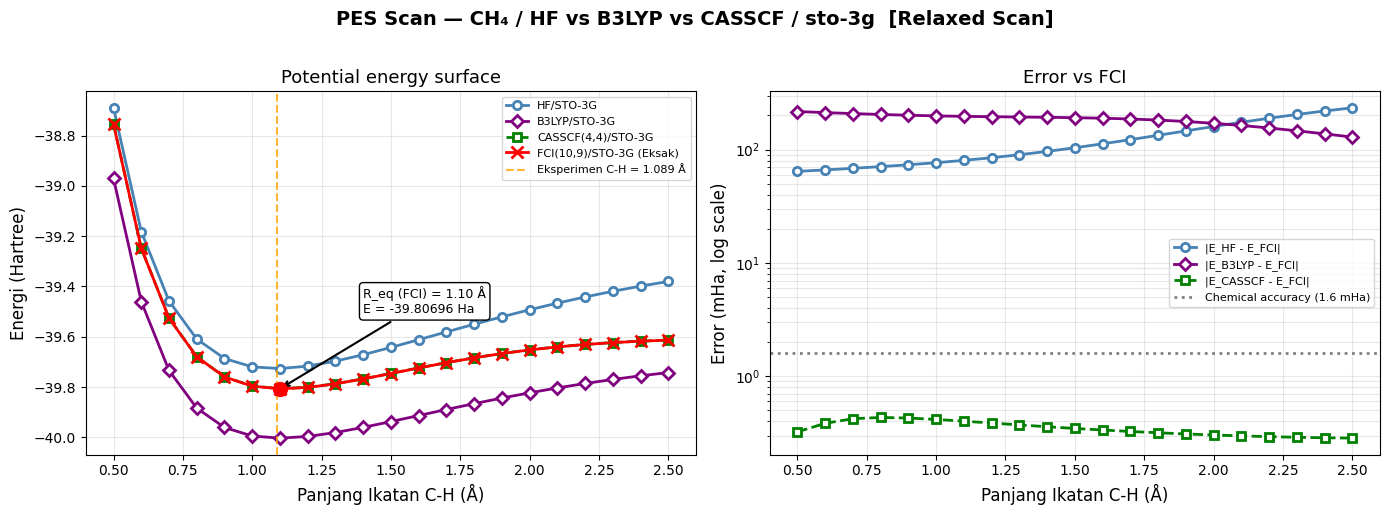

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ── Plot 1: PES ──
ax1.plot(R, E_HF,     'o-',  color='steelblue', linewidth=2,
         markersize=6, markerfacecolor='white', markeredgewidth=2,
         label='HF/STO-3G')
ax1.plot(R, E_DFT,    'D-',  color='purple',    linewidth=2,
         markersize
         =6, markerfacecolor='white', markeredgewidth=2,
         label='B3LYP/STO-3G')
ax1.plot(R, E_CASSCF, 's--', color='green',     linewidth=2,
         markersize=6, markerfacecolor='white', markeredgewidth=2,
         label='CASSCF(8,8)/STO-3G')
ax1.plot(R, E_FCI,    'x-',  color='red',       linewidth=2,
         markersize=8, markeredgewidth=2,
         label='FCI(10,9)/STO-3G (Eksak)')

ax1.plot(R[idx_fci], E_FCI[idx_fci], 'ro', markersize=10, zorder=5)
ax1.annotate(f'R_eq (FCI) = {R[idx_fci]:.2f} Å\nE = {E_FCI[idx_fci]:.5f} Ha',
             xy=(R[idx_fci], E_FCI[idx_fci]),
             xytext=(R[idx_fci]+0.3, E_FCI[idx_fci]+0.3),
             arrowprops=dict(arrowstyle='->', color='black', lw=1.5),
             fontsize=9,
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                       edgecolor='black', linewidth=1))

ax1.axvline(x=1.089, color='orange', linestyle='--',
            linewidth=1.5, alpha=0.8, label='Eksperimen C-H = 1.089 Å')
ax1.set_xlabel('Panjang Ikatan C-H (Å)', fontsize=12)
ax1.set_ylabel('Energi (Hartree)', fontsize=12)
ax1.set_title('Potential energy surface', fontsize=13)
ax1.legend(fontsize=8, loc='upper right')
ax1.grid(True, alpha=0.3)

# ── Plot 2: Error vs FCI (dikonversi ke mHa, sesuai skala contoh) ──
error_hf_mHa     = error_hf     * 1000
error_dft_mHa    = error_dft    * 1000
error_casscf_mHa = error_casscf * 1000
CA_mHa = CA * 1000  # 1.6 mHa

ax2.semilogy(R, error_hf_mHa,     'o-',  color='steelblue', linewidth=2,
             markersize=6, markerfacecolor='white', markeredgewidth=2,
             label='|E_HF - E_FCI|')
ax2.semilogy(R, error_dft_mHa,    'D-',  color='purple',    linewidth=2,
             markersize=6, markerfacecolor='white', markeredgewidth=2,
             label='|E_B3LYP - E_FCI|')
ax2.semilogy(R, error_casscf_mHa, 's--', color='green',     linewidth=2,
             markersize=6, markerfacecolor='white', markeredgewidth=2,
             label='|E_CASSCF - E_FCI|')
ax2.axhline(y=CA_mHa, color='gray', linestyle=':',
            linewidth=2, label='Chemical accuracy (1.6 mHa)')
ax2.set_xlabel('Panjang Ikatan C-H (Å)', fontsize=12)
ax2.set_ylabel('Error (mHa, log scale)', fontsize=12)
ax2.set_title('Error vs FCI', fontsize=13)
ax2.legend(fontsize=8, loc='best')
ax2.grid(True, alpha=0.3, which='both')

plt.suptitle('PES Scan — CH₄ / HF vs B3LYP vs CASSCF / sto-3g  [Relaxed Scan]',
              fontsize=14, weight='bold', y=1.02)
plt.tight_layout()
plt.savefig('PES_CH4_benchmark_OPT.png', dpi=150, bbox_inches='tight')
plt.show()